## Tarea N1

In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [7]:
ativos = ["AAPL", "MSFT", "TSLA"]

dados_raw = yf.download(ativos, start="2020-01-01")

dados = dados_raw["Close"]

dados.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-02,72.400513,152.158386,28.684000
2020-01-03,71.696617,150.263763,29.534000
2020-01-06,72.267937,150.652130,30.102667
2020-01-07,71.928055,149.278595,31.270666
2020-01-08,73.085114,151.656296,32.809334


In [8]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1591 entries, 2020-01-02 to 2026-05-01
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1591 non-null   float64
 1   MSFT    1591 non-null   float64
 2   TSLA    1591 non-null   float64
dtypes: float64(3)
memory usage: 49.7 KB


In [9]:
dados.isna().sum()

Ticker
AAPL    0
MSFT    0
TSLA    0
dtype: int64

In [10]:
dados.describe()

Ticker,AAPL,MSFT,TSLA
count,1591.000000,1591.000000,1591.000000
mean,169.834958,320.559588,245.796090
std,52.966339,100.980060,101.743202
min,54.213604,128.636368,24.081333
25%,133.322334,237.823532,186.250000
50%,167.297470,304.528198,239.199997
75%,210.396454,408.567413,308.851669
max,285.922455,539.825256,489.880005


Retornos diarios

In [11]:
retornos = dados.pct_change().dropna()

retornos.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-03,-0.009722,-0.012452,0.029633
2020-01-06,0.007969,0.002585,0.019255
2020-01-07,-0.004703,-0.009117,0.038801
2020-01-08,0.016086,0.015928,0.049205
2020-01-09,0.021241,0.012493,-0.021945


Retornos acumulados

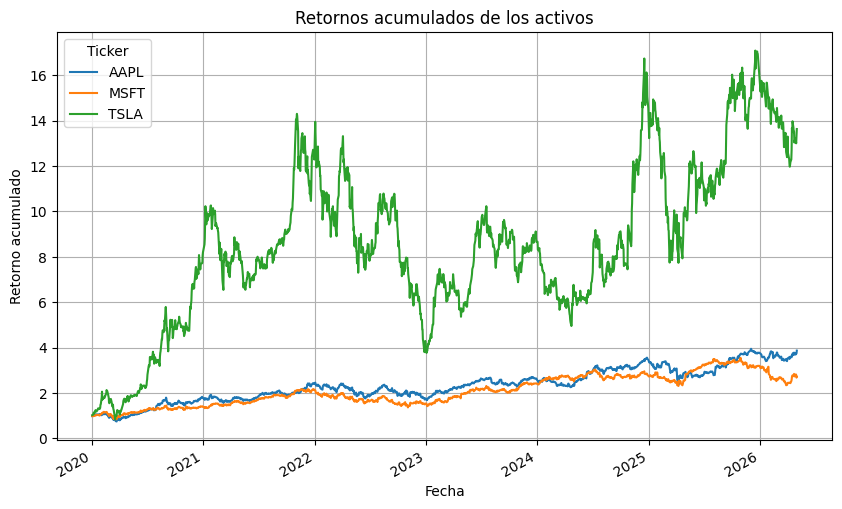

In [12]:
retornos_acumulados = (1 + retornos).cumprod()

retornos_acumulados.plot(
    figsize=(10, 6),
    title="Retornos acumulados de los activos",
    grid=True
)

plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.show()

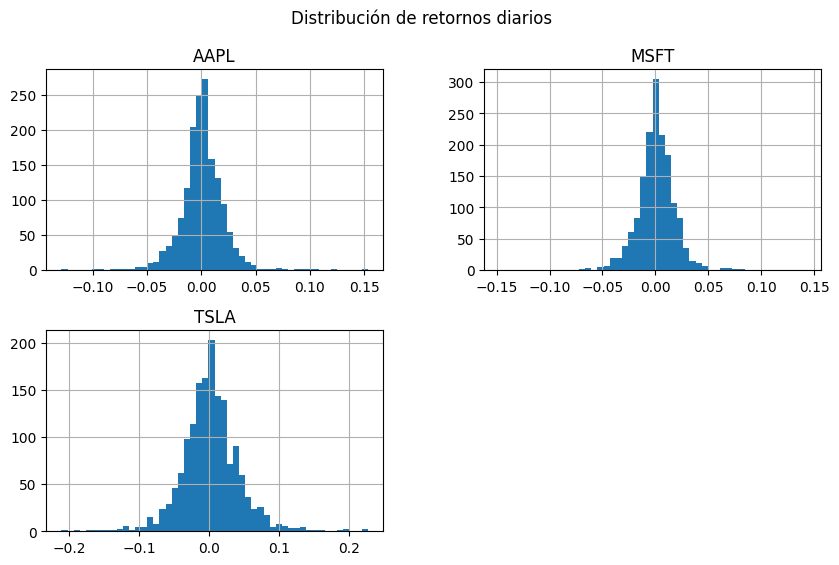

In [13]:
retornos.hist(
    bins=50,
    figsize=(10, 6)
)

plt.suptitle("Distribución de retornos diarios")
plt.show()

Calidad

In [14]:
reporte_calidad = pd.DataFrame({
    "filas": dados.shape[0],
    "valores_faltantes": dados.isna().sum(),
    "porcentaje_faltantes": dados.isna().mean() * 100,
    "valor_minimo": dados.min(),
    "valor_maximo": dados.max(),
    "media": dados.mean(),
    "desviacion_estandar": dados.std()
})

reporte_calidad

,filas,valores_faltantes,porcentaje_faltantes,valor_minimo,valor_maximo,media,desviacion_estandar
Ticker,,,,,,,
AAPL,1591,0,0.0,54.213604,285.922455,169.834958,52.966339
MSFT,1591,0,0.0,128.636368,539.825256,320.559588,100.980060
TSLA,1591,0,0.0,24.081333,489.880005,245.796090,101.743202


## Análisis de resultados

Se descargaron datos históricos de tres activos: AAPL, MSFT y TSLA.

El gráfico de retornos acumulados muestra que TSLA presenta un comportamiento más volátil y mayores variaciones en comparación con AAPL y MSFT. AAPL y MSFT presentan una evolución más estable durante el período analizado.

Las distribuciones de retornos diarios permiten observar la dispersión de los retornos de cada activo. TSLA muestra mayor volatilidad, mientras que AAPL y MSFT presentan distribuciones más concentradas.

El reporte de calidad de datos permite verificar la existencia de valores faltantes, el rango de precios y estadísticas básicas de cada activo.